In [1]:
from cs336_data.data_quality import *
from cs336_data.deduplication import *
from cs336_data.language_modeling import *
import timeit
import multiprocessing
# from tqdm.notebook import tqdm 
from tqdm import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Data quality filtering

In [ ]:
gstart = timeit.default_timer()

def english_wet_packer(args):
    return english_wet(*args)

dir_path = Path("./data/common_crawl_raw/")
argments = list()
for file_path in dir_path.iterdir():
    if file_path.is_file():
        filename = str(file_path.name).split(".")[0]
        output_name = f"./data/common_crawl_en/{filename}.txt"
        if Path(output_name).exists():
            continue
        argments.append((str(file_path), output_name))

with multiprocessing.Pool(processes=16) as pool:
    for _ in tqdm(pool.imap(english_wet_packer, argments), total=len(argments), desc="Processing Files"):
        pass

gstop = timeit.default_timer()
print(f"Total Execution Time: {(gstop - gstart)/60:.2f} minutes")

Processing Files:   0%|          | 0/1477 [00:00<?, ?it/s]

Total Execution Time: 61.61 minutes


In [2]:
gstart = timeit.default_timer()

def quality_filter(input_file, output_file, threshold=0.5):
    with open(input_file, "r") as fin, open(output_file, "w") as fout:
        for text in fin.readlines():
            label, conf = classify_quality(text)
            if label == "wiki" and conf >= threshold:
                fout.write(f"{text}")

def quality_filter_packer(args):
    return quality_filter(*args)

threshold = 0.8
dir_path = Path("./data/common_crawl_en/")
argments = list()
for file_path in dir_path.iterdir():
    if file_path.is_file():
        filename = str(file_path.name).split(".")[0]
        output_name = f"./data/common_crawl_filter/{filename}.txt"
        argments.append((str(file_path), output_name, threshold))

with multiprocessing.Pool(processes=16) as pool:
    for _ in tqdm(pool.imap(quality_filter_packer, argments), total=len(argments), desc="Processing Files"):
        pass

gstop = timeit.default_timer()
print(f"Total Execution Time: {(gstop - gstart)/60:.2f} minutes")

Processing Files:   0%|          | 0/1567 [00:00<?, ?it/s]

Total Execution Time: 7.81 minutes


In [2]:
gstart = timeit.default_timer()

dir_path = Path("./data/common_crawl_filter/")
output_dir = "./data/common_crawl_dedup/"
minhash_deduplication(
    input_files = [str(file_path) for file_path in dir_path.iterdir() if file_path.is_file()],
    output_directory = output_dir,
    num_hashes = 100,
    num_bands = 10,
    num_ngrams = 5,
    jaccard_threshold = 0.8,
)

output_name = f"./data/cc_en.txt"
dir_path = Path("./data/common_crawl_dedup/")
if os.path.exists(output_name):
    os.remove(output_name)
for file_path in dir_path.iterdir():
    if file_path.is_file():
        with open(file_path, "r") as fin, open(output_name, "a") as fout:
            fout.write(fin.read())

with open(output_name, "r") as file:
    line_count = sum(1 for line in file)

print(f"Total lines: {line_count}")

gstop = timeit.default_timer()
print(f"Total Execution Time: {(gstop - gstart)/60:.2f} minutes")

Processed 30 out of 1567 files
Processed 60 out of 1567 files
Processed 90 out of 1567 files
Processed 120 out of 1567 files
Processed 150 out of 1567 files
Processed 180 out of 1567 files
Processed 210 out of 1567 files
Processed 240 out of 1567 files
Processed 270 out of 1567 files
Processed 300 out of 1567 files
Processed 330 out of 1567 files
Processed 360 out of 1567 files
Processed 390 out of 1567 files
Processed 420 out of 1567 files
Processed 450 out of 1567 files
Processed 480 out of 1567 files
Processed 510 out of 1567 files
Processed 540 out of 1567 files
Processed 570 out of 1567 files
Processed 600 out of 1567 files
Processed 630 out of 1567 files
Processed 660 out of 1567 files
Processed 690 out of 1567 files
Processed 720 out of 1567 files
Processed 750 out of 1567 files
Processed 780 out of 1567 files
Processed 810 out of 1567 files
Processed 840 out of 1567 files
Processed 870 out of 1567 files
Processed 900 out of 1567 files
Processed 930 out of 1567 files
Processed 9

In [2]:
from transformers import AutoTokenizer
import re
from typing import List
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

def _text_clean(text: str) -> List[str]:
    return " ".join(re.sub(r"\s+", " ", text).strip().split())

def tokenize(text: str, tokenizer) -> List[int]:
    text = _text_clean(text)
    tokens = tokenizer(text, padding=True, truncation=False, return_tensors="np")
    return tokens["input_ids"].flatten().tolist() + [tokenizer.eos_token_id]

input_file_path = f"./data/cc_en.txt"
with open(input_file_path, 'r', encoding='utf-8') as infile, open("./temp.txt", "w") as outfile:
    for i in range(10):
        text = next(infile)
        tokens = tokenize(text, tokenizer)
        outfile.write(f"{i}: {tokens}\n")
print(tokenizer.eos_token_id)

Token indices sequence length is longer than the specified maximum sequence length for this model (3823 > 1024). Running this sequence through the model will result in indexing errors


50256


## Tokenization

In [2]:
from transformers import AutoTokenizer
import re
from typing import List
import numpy as np
from multiprocessing import cpu_count, Pool

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

def _text_clean(text: str) -> str:
    return " ".join(re.sub(r"\s+", " ", text).strip().split())

def tokenize(text: str, tokenizer) -> List[int]:
    text = _text_clean(text)
    tokens = tokenizer(text, padding=False, truncation=False, return_tensors="np")
    return tokens["input_ids"].flatten().tolist() + [tokenizer.eos_token_id]

def tokenize_wrapper(text):
    return tokenize(text, tokenizer)

In [ ]:
gstart = timeit.default_timer()

# def save_encoded(encoded, encoded_filepath):
#     with open(encoded_filepath, "ab") as f:
#         np.array(encoded, dtype=np.uint16).tofile(f)

input_file_path = f"./data/cc_en.txt"
output_file_path = f"./data/cc_en_encoded.bin"
if os.path.exists(output_file_path):
    os.remove(output_file_path)

with open(input_file_path, 'r', encoding='utf-8') as infile:
    print("Counting lines...")
    num_lines = sum(1 for _ in infile)
    infile.seek(0) # Reset file pointer back to the beginning

    num_workers = max(1, cpu_count() - 1)
    buffer = []

    with Pool(processes=num_workers) as pool, open(output_file_path, "ab") as fout:
        results = pool.imap(tokenize_wrapper, infile, chunksize=500)
        for chunk in tqdm(results, total=num_lines, desc="Tokenizing File"):
            buffer.extend(chunk)
            if len(buffer) >= 1_000_000:
                np.array(buffer, dtype=np.uint16).tofile(fout)
                buffer = []
        if buffer:
            np.array(buffer, dtype=np.uint16).tofile(fout)

gstop = timeit.default_timer()
print(f"Total Execution Time: {(gstop - gstart)/60:.2f} minutes")

Counting lines...


Tokenizing File:   0%|          | 0/59995 [00:00<?, ?it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (3823 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (7362 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1596 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (3135 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (13931 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequenc

Total Execution Time: 1.13 minutes


In [3]:
from datasets import load_dataset, load_from_disk

gstart = timeit.default_timer()

dataset = load_from_disk("./data/paloma_c4_100")
output_file_path = f"./data/paloma_c4_100_val.bin"
if os.path.exists(output_file_path):
    os.remove(output_file_path)

with open(output_file_path, "ab") as fout:
    for element in dataset["val"]:
        tokens = tokenize_wrapper(element["text"])
        np.array(tokens, dtype=np.uint16).tofile(fout)

gstop = timeit.default_timer()
print(f"Total Execution Time: {(gstop - gstart)/60:.2f} minutes")

Token indices sequence length is longer than the specified maximum sequence length for this model (2196 > 1024). Running this sequence through the model will result in indexing errors


Total Execution Time: 0.23 minutes


In [9]:
from datasets import load_dataset, load_from_disk

dataset = load_from_disk("./data/paloma_c4_100")
count = 0
for element in dataset["val"]:
    text = _text_clean(element["text"])
    print(text)
    count += 1
    if count >= 10:
        break

What does the future hold for Star Wars animation? It's a sad day for fans of Star Wars: The Clone Wars... from a certain point of view. Lucasfilm and The Clone Wars' supervising director, Dave Filoni, have announced that Star Wars: The Clone Wars, the television series, is over and that the fifth season that just came to an end was the final one for the show. But here's where it gets complicated. More episodes of The Clone Wars have been made than what we've seen. There were in fact glimpses in the trailer for Season 5 of a storyline that ended up being held, and there have been other references made by Filoni and others, as far back as Star Wars Celebration VI last summer, indicating more stories were being produced for a presumed sixth season. In fact, when I recently spoke to Filoni for a Post-Season 5 interview, he told me, "There are more stories to tell, and as I’ve said, we’ve been working on them for awhile." There won't be a sixth season, but the announcement did promise, "We

## Model training

In [2]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler("./language_modeling.log"),
        logging.StreamHandler(),
    ]
)

gstart = timeit.default_timer()

## Initialize hyperparameters
hyperparams = {
    "batch_size": 64,
    "gradient_accumulation_step": 16,
    "context_length": 256,
    "vocab_size": 50257,
    "d_model": 512,
    "num_layers": 4,
    "num_heads": 16,
    "d_ff": 1344,
    "rope_theta": 10000.0,
    "betas": (0.9, 0.999),
    "lr_min": 1e-4,
    "lr_max": 3e-3,
    "weight_decay": 0.1,
    "eps": 1e-8,
    "max_iter": 16_384,
    "warmup_iters": 300,
    "cosine_cycle_iters": 9900,
    "max_grad_norm": 1.0,
    "training_dtype": "bfloat16",
    "continue_from": 10700
}
train_data_filename = "./data/cc_en_encoded.bin"
valid_data_filename = "./data/paloma_c4_100_val.bin"
model_train(
    train_data_filename = train_data_filename,
    valid_data_filename = valid_data_filename,
    checkpoint_path = "./model/",
    model_prefix = "cc_model",
    **hyperparams
)

gstop = timeit.default_timer()
print(f"Total Execution Time: {(gstop - gstart)/60:.2f} minutes")

2026-08-07 21:45:03,522 [INFO] number of non-embedding parameters: 12.46M
2026-08-07 21:45:17,539 [INFO] Validation loss at step 10700: 4.452540
2026-08-07 22:05:46,674 [INFO] Validation loss at step 10800: 4.437476
2026-08-07 22:28:06,427 [INFO] Validation loss at step 10900: 4.471541
2026-08-07 22:54:03,257 [INFO] Validation loss at step 11000: 4.447235
2026-08-07 23:18:56,995 [INFO] Validation loss at step 11100: 4.514647
2026-08-07 23:39:06,024 [INFO] Validation loss at step 11200: 4.480863
2026-08-07 23:55:21,654 [INFO] Validation loss at step 11300: 4.440740
2026-08-08 00:16:20,152 [INFO] Validation loss at step 11400: 4.462208
2026-08-08 00:37:24,299 [INFO] Validation loss at step 11500: 4.421626
2026-08-08 00:55:23,392 [INFO] Validation loss at step 11600: 4.478354
2026-08-08 01:09:57,747 [INFO] Validation loss at step 11700: 4.468862
2026-08-08 01:24:30,154 [INFO] Validation loss at step 11800: 4.471320
2026-08-08 01:39:07,091 [INFO] Validation loss at step 11900: 4.454956
202

Total Execution Time: 955.04 minutes


In [3]:
import torch
import torch.nn.functional as F
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import pandas as pd

gstart = timeit.default_timer()

## Initialize hyperparameters
hyperparams = {
    "batch_size": 64,
    "gradient_accumulation_step": 16,
    "context_length": 256,
    "vocab_size": 50257,
    "d_model": 512,
    "num_layers": 4,
    "num_heads": 16,
    "d_ff": 1344,
    "rope_theta": 10000.0,
    "betas": (0.9, 0.999),
    "lr_min": 1e-4,
    "lr_max": 3e-3,
    "weight_decay": 0.1,
    "eps": 1e-8,
    "max_iter": 16_384,
    "warmup_iters": 300,
    "cosine_cycle_iters": 9900,
    "max_grad_norm": 1.0,
    "training_dtype": "bfloat16",
    "continue_from": 10700
}

valid_data_filename = "./data/paloma_c4_100_val.bin"
checkpoint_path = "./model/"
model_prefix = "cc_model"

valid_data = np.memmap(valid_data_filename, dtype=np.uint16, mode="r")

model_hyperparams = {
    "vocab_size": hyperparams["vocab_size"], 
    "context_length": hyperparams["context_length"], 
    "d_model": hyperparams["d_model"], 
    "num_layers": hyperparams["num_layers"], 
    "num_heads": hyperparams["num_heads"], 
    "d_ff": hyperparams["d_ff"], 
    "rope_theta": hyperparams["rope_theta"]
}

# param_dict = {pn: p for pn, p in model.named_parameters() if p.requires_grad}
# params_to_decay = [p for _, p in param_dict.items() if p.dim() >= 2]
# params_to_not_decay = [p for _, p in param_dict.items() if p.dim() < 2]
# optim_groups = [
#     {"params": params_to_decay, "weight_decay": hyperparams["weight_decay"]},
#     {"params": params_to_not_decay, "weight_decay": 0.0},
# ]
# optimizer = torch.optim.AdamW(
#     optim_groups,
#     lr = hyperparams["lr_max"],
#     betas = hyperparams["betas"],
#     eps = hyperparams["eps"],
#     fused = True,
# )

eval_iters = 1000
eval_batch_size = 128
output_filename = "./evaluation_results.csv"
if Path(output_filename).is_file():
    res_dict = pd.read_csv(output_filename).to_dict(orient="list")
else:
    res_dict = {
        "model_id": list(),
        "eval_loss": list(),
        "eval_perplexity": list()
    }
index_range = [i for i in range(0, hyperparams["max_iter"] + 1, 100)]

for index in index_range:
    model = BasicsTransformerLM(**model_hyperparams).to(device)
    if index in res_dict["model_id"] or not Path(os.path.join(checkpoint_path, f"./{model_prefix}_{index}.pt")).is_file():
        continue
    load_checkpoint(os.path.join(checkpoint_path, f"./{model_prefix}_{index}.pt"), model)

    model.eval()
    with torch.no_grad():
        valid_loss = torch.zeros(eval_iters, device=device)
        for k in tqdm(range(eval_iters)):
            X_valid, y_valid = get_batch(
                valid_data,
                batch_size = eval_batch_size,
                context_length = hyperparams["context_length"],
                device = str(device)
            )
            y_pred = model(X_valid)
            valid_loss[k] = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_valid.view(-1)).item()
        res_dict["model_id"].append(index)
        res_dict["eval_loss"].append(valid_loss.mean().item())
        res_dict["eval_perplexity"].append(torch.exp(valid_loss.mean()).item())
    # model.train()
    pd.DataFrame(res_dict).sort_values(by="model_id").to_csv(output_filename, index=False)

    del model

gstop = timeit.default_timer()
print(f"Total Execution Time: {(gstop - gstart)/60:.2f} minutes")

100%|██████████| 1000/1000 [03:35<00:00,  4.64it/s]

Total Execution Time: 461.12 minutes


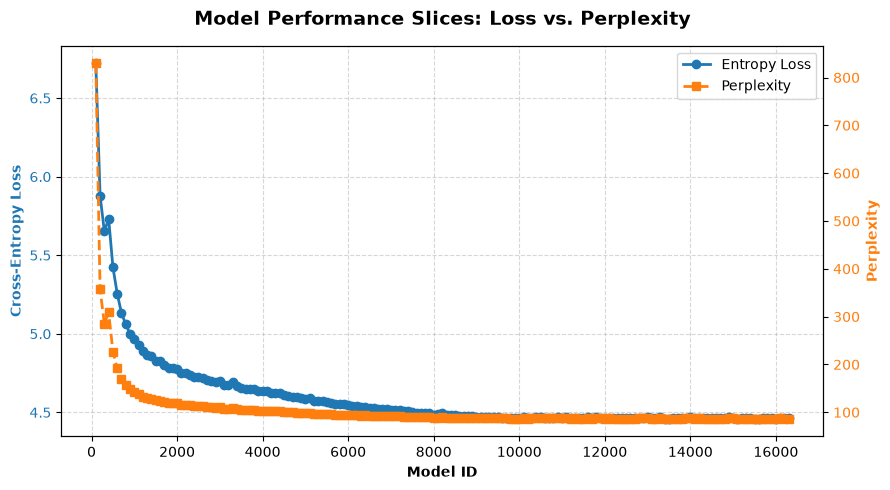

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(output_filename).sort_values('model_id')

# 2. Initialize the plot
fig, ax1 = plt.subplots(figsize=(9, 5))

# 3. Plot Entropy Loss on the Left Axis
color_loss = '#1f77b4'  # Blue
ax1.set_xlabel('Model ID', fontweight='bold')
ax1.set_ylabel('Cross-Entropy Loss', color=color_loss, fontweight='bold')
line1 = ax1.plot(df['model_id'], df['eval_loss'], color=color_loss, marker='o', linewidth=2, label='Entropy Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.grid(True, linestyle='--', alpha=0.5)

# 4. Create the second Y-axis for Perplexity
ax2 = ax1.twinx()
color_ppl = '#ff7f0e'  # Orange
ax2.set_ylabel('Perplexity', color=color_ppl, fontweight='bold')
line2 = ax2.plot(df['model_id'], df['eval_perplexity'], color=color_ppl, marker='s', linewidth=2, linestyle='--', label='Perplexity')
ax2.tick_params(axis='y', labelcolor=color_ppl)

# Optional: Turn on log scale if your perplexity values span orders of magnitude
# ax2.set_yscale('log')

# 5. Unify legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Model Performance Slices: Loss vs. Perplexity', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()